# Test de Inferencia — VishingModelWrapper

Notebook de prueba end-to-end que carga un modelo entrenado y lo ejercita con JSONs sintéticos,
simulando exactamente el flujo que recibiría un servicio de scoring en producción.

## Flujo
1. Cargar wrapper desde S3 (o disco local como fallback)
2. Inspeccionar features esperadas
3. Construir 3 sesiones sintéticas: legítima, vishing clara, caso ambiguo
4. Obtener predicciones con los tres métodos de la API
5. Test de batch y validación de errores
6. Visualización comparativa de scores

## 1. Setup

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from io import BytesIO
from urllib.parse import urlparse
from pathlib import Path

print('Librerías cargadas.')

Librerías cargadas.


## 2. Definición de VishingModelWrapper

La clase debe estar definida en este notebook antes de que `joblib` pueda deserializar el archivo `.pkl`.

In [2]:
class VishingModelWrapper:
    """
    Bundles a trained classifier with its scaler, ordered feature list, and
    optimal decision threshold so that inference can be driven purely by a
    named-feature JSON — no positional assumptions required.

    Supports single observations (dict or JSON string) and batches (list of dicts).
    """

    def __init__(self, model, feature_names, scaler=None, threshold=0.5,
                 model_name="", technique="", ratio=""):
        self.model         = model
        self.feature_names = list(feature_names)
        self.scaler        = scaler
        self.threshold     = threshold
        self.model_name    = model_name
        self.technique     = technique
        self.ratio         = ratio

    def _to_array(self, json_input):
        if isinstance(json_input, str):
            data = json.loads(json_input)
        elif isinstance(json_input, dict):
            data = json_input
        elif isinstance(json_input, list):
            return np.vstack([self._to_array(item) for item in json_input])
        else:
            raise TypeError(f"Expected dict, JSON string, or list of dicts. Got {type(json_input)}")

        missing = set(self.feature_names) - set(data.keys())
        if missing:
            raise ValueError(f"Missing features: {sorted(missing)}")

        X = np.array([[data[f] for f in self.feature_names]], dtype=np.float64)
        if self.scaler is not None:
            X = self.scaler.transform(X)
        return X

    def predict(self, json_input):
        """Returns 0 (legitimate) or 1 (vishing) using the stored threshold."""
        proba  = self.model.predict_proba(self._to_array(json_input))[:, 1]
        labels = (proba >= self.threshold).astype(int).tolist()
        return labels[0] if len(labels) == 1 else labels

    def predict_proba_raw(self, json_input):
        """Returns {'legitimate': float, 'vishing': float} per observation."""
        proba = self.model.predict_proba(self._to_array(json_input))
        rows  = [{"legitimate": round(float(p[0]), 6),
                  "vishing":    round(float(p[1]), 6)} for p in proba]
        return rows[0] if len(rows) == 1 else rows

    def predict_full(self, json_input):
        """
        Full inference result: prediction, label, probabilities, threshold_used.
        Accepts dict, JSON string, or list[dict] for batch.
        """
        proba   = self.model.predict_proba(self._to_array(json_input))
        results = []
        for p in proba:
            label = int(p[1] >= self.threshold)
            results.append({
                "prediction":             label,
                "label":                  "vishing" if label == 1 else "legitimate",
                "probability_vishing":    round(float(p[1]), 6),
                "probability_legitimate": round(float(p[0]), 6),
                "threshold_used":         round(self.threshold, 6),
            })
        return results[0] if len(results) == 1 else results

    def __repr__(self):
        return (f"VishingModelWrapper(model={self.model_name!r}, "
                f"technique={self.technique!r}, ratio={self.ratio!r}, "
                f"n_features={len(self.feature_names)}, threshold={self.threshold:.4f})")

print("VishingModelWrapper definida correctamente.")


VishingModelWrapper definida correctamente.


## 3. Cargar el Wrapper

Modifica `USE_S3 = True` si estás en SageMaker con acceso al bucket.
Con `USE_S3 = False` carga desde la carpeta local `modelos_temp/` generada durante el entrenamiento.

In [3]:
# ── Configuración ─────────────────────────────────────────────────────────────
USE_S3 = True   # False → carga desde disco local

# S3
BUCKET     = 'poc-fraude-vishing'
TECHNIQUE  = 'random_oversampling'         # borderline_smote | random_oversampling | smote | smote_undersampling
RATIO      = '10'            # 10 | 20 | 25
MODEL_NAME = 'XGBoost'       # Logistic_Regression | Random_Forest | XGBoost | Deep_Learning_PyTorch

S3_MODEL_KEY = f'proyecto/modelos/{TECHNIQUE}/{RATIO}/{MODEL_NAME}.pkl'

# Local (fallback)
LOCAL_PATH = Path(f'modelos_temp/{TECHNIQUE}/{RATIO}/{MODEL_NAME}.pkl')

# ── Carga ────────────────────────────────────────────────────────────────────
wrapper = None

if USE_S3:
    try:
        import boto3
        s3 = boto3.client('s3')
        print(f'Descargando desde s3://{BUCKET}/{S3_MODEL_KEY} ...')
        with BytesIO() as f:
            s3.download_fileobj(Bucket=BUCKET, Key=S3_MODEL_KEY, Fileobj=f)
            f.seek(0)
            wrapper = joblib.load(f)
        print('Wrapper cargado desde S3.')
    except Exception as e:
        print(f'[WARN] S3 no disponible ({e}). Intentando carga local...')
        USE_S3 = False

if not USE_S3:
    if LOCAL_PATH.exists():
        wrapper = joblib.load(LOCAL_PATH)
        print(f'Wrapper cargado desde disco: {LOCAL_PATH}')
    else:
        raise FileNotFoundError(
            f'No se encontró el wrapper en {LOCAL_PATH}.\n'
            'Ejecuta primero el notebook 7_Modeling_Vishing_AD_AWS_exec.ipynb.'
        )

print(f'\n{wrapper}')

Descargando desde s3://poc-fraude-vishing/proyecto/modelos/random_oversampling/10/XGBoost.pkl ...
Wrapper cargado desde S3.

VishingModelWrapper(model='XGBoost', technique='random_oversampling', ratio='10', n_features=44, threshold=0.7161)


## 4. Inspección del Wrapper

In [4]:
print('═' * 60)
print(f'  Modelo      : {wrapper.model_name}')
print(f'  Técnica     : {wrapper.technique}')
print(f'  Ratio       : {wrapper.ratio}%')
print(f'  Umbral      : {wrapper.threshold:.4f}')
print(f'  Scaler      : {"StandardScaler" if wrapper.scaler is not None else "No aplica (árbol)"}')
print(f'  N features  : {len(wrapper.feature_names)}')
print('═' * 60)
print()
print('Features esperadas (en orden):')
for i, feat in enumerate(wrapper.feature_names):
    print(f'  [{i:2d}] {feat}')

════════════════════════════════════════════════════════════
  Modelo      : XGBoost
  Técnica     : random_oversampling
  Ratio       : 10%
  Umbral      : 0.7161
  Scaler      : No aplica (árbol)
  N features  : 44
════════════════════════════════════════════════════════════

Features esperadas (en orden):
  [ 0] avg_keyhold_ms
  [ 1] avg_interkey_latency_ms
  [ 2] typing_speed_cps
  [ 3] keystroke_variability
  [ 4] segmented_typing_ratio
  [ 5] avg_touch_pressure
  [ 6] avg_touch_size_px
  [ 7] swipe_speed_px_s
  [ 8] swipe_directional_variance
  [ 9] scroll_speed_avg
  [10] device_tilt_angle_mean
  [11] device_tilt_variability
  [12] gyro_rotation_rate_mean
  [13] accelerometer_jerk_mean
  [14] avg_hesitation_duration_s
  [15] max_hesitation_duration_s
  [16] total_dead_time_s
  [17] dead_time_ratio
  [18] screen_transition_time_avg_s
  [19] data_familiarity_score
  [20] session_duration_s
  [21] call_overlap_duration_s
  [22] time_to_transaction_s
  [23] errors_per_minute
  [24] 

## 5. Validación con Datos Reales — S3

Antes de usar JSONs sintéticos, validamos que el modelo discrimina correctamente sobre muestras
reales extraídas del mismo dataset con el que fue entrenado. Esto confirma que el wrapper
funciona correctamente end-to-end.

In [23]:
import boto3

# ── Columnas que se dropean antes del entrenamiento (igual que en notebook 7) ─
COLS_TO_DROP = [
    'session_id', 'customer_id', 'session_timestamp',
    'device_type', 'os_type', 'app_version',
    'biocatch_risk_score', 'biocatch_genuine_score', 'biocatch_ato_indicator',
    'biocatch_social_eng_indicator', 'biocatch_bot_indicator',
    'days_to_claim', 'claim_category',
    'screens_visited', 'unusual_screen_visits', 'is_synthetic', 'interactions_per_s',
    'is_vishing',
]

# ── Cargar una muestra pequeña del parquet desde S3 ──────────────────────────
S3_DATA_KEY = 'proyecto/data/augmented_data/dataset_1M_vishing_.parquet'
N_LEGIT    = 5
N_VISHING  = 5

print(f'Cargando muestra desde s3://{BUCKET}/{S3_DATA_KEY} ...')
s3_data = boto3.client('s3')
with BytesIO() as buf:
    s3_data.download_fileobj(Bucket=BUCKET, Key=S3_DATA_KEY, Fileobj=buf)
    buf.seek(0)
    df_full = pd.read_parquet(buf)

# Separar por clase y tomar muestras
df_legit   = df_full[df_full['is_vishing'] == 0].sample(N_LEGIT,   random_state=1)
df_vishing = df_full[df_full['is_vishing'] == 1].sample(N_VISHING, random_state=1)
df_sample  = pd.concat([df_legit, df_vishing]).reset_index(drop=True)
y_real     = df_sample['is_vishing'].tolist()

# Aplicar mismos drops que el entrenamiento y quedarse con las features del wrapper
df_features = df_sample.drop(columns=[c for c in COLS_TO_DROP if c in df_sample.columns])
df_features = df_features[wrapper.feature_names]  # orden canónico del wrapper

print(f'Muestras cargadas: {N_LEGIT} legítimas + {N_VISHING} vishing\n')

# ── Inferencia vía wrapper (path de producción) ───────────────────────────────
records = df_features.to_dict(orient='records')
results_real = wrapper.predict_full(records)

# ── Mostrar resultados ────────────────────────────────────────────────────────
print(f'{"#":<4} {"Clase real":>12}  {"Predicción":>12}  {"P_vishing":>12}  {"Correcto"}')
print('─' * 60)
correct = 0
for i, (real, res) in enumerate(zip(y_real, results_real)):
    real_label = 'vishing'   if real == 1 else 'legitimate'
    pred_label = res['label']
    ok         = '✅' if real_label == pred_label else '❌'
    if real_label == pred_label:
        correct += 1
    print(f'{i:<4} {real_label:>12}  {pred_label:>12}  {res["probability_vishing"]:>12.6f}  {ok}')

print(f'\nAciertos: {correct}/{N_LEGIT + N_VISHING}')
print(f'Umbral usado: {wrapper.threshold:.4f}')


Cargando muestra desde s3://poc-fraude-vishing/proyecto/data/augmented_data/dataset_1M_vishing_.parquet ...
Muestras cargadas: 5 legítimas + 5 vishing

#      Clase real    Predicción     P_vishing  Correcto
────────────────────────────────────────────────────────────
0      legitimate    legitimate      0.000313  ✅
1      legitimate    legitimate      0.060784  ✅
2      legitimate    legitimate      0.000437  ✅
3      legitimate    legitimate      0.000041  ✅
4      legitimate    legitimate      0.000136  ✅
5         vishing    legitimate      0.358967  ❌
6         vishing       vishing      0.962582  ✅
7         vishing       vishing      0.973776  ✅
8         vishing    legitimate      0.598966  ❌
9         vishing    legitimate      0.586955  ❌

Aciertos: 7/10
Umbral usado: 0.7161


## 6. Sesiones Sintéticas — Ilustración Conceptual

Tres perfiles construidos manualmente a partir de los rangos del EDA (`5_EDA_augmented_data.ipynb`).

> **Nota:** Los modelos entrenados sobre 1M sesiones reales aprenden combinaciones de features
> muy específicas. Los JSONs sintéticos ilustran los patrones conceptuales de cada perfil, pero
> pueden no alcanzar el umbral de decisión si los valores no replican exactamente las distribuciones
> del conjunto de entrenamiento. Para validación funcional usa la sección anterior (datos reales).

| Variable clave | Legítima | Vishing | Ambigua |
|---|---|---|---|
| `phone_call_active` | 0 | 1 | 1 |
| `segmented_typing_ratio` | 0.14 | 0.27 | 0.19 |
| `data_familiarity_score` | 0.68 | 0.53 | 0.62 |
| `hesitation_count` | 4 | 8 | 5 |
| `amount_field_corrections` | 0 | 3 | 1 |
| `remote_access_tool_detected` | 0 | 1 | 0 |
| `transaction_amount_cop` | 150,000 | 9,200,000 | 650,000 |

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Sesión LEGÍTIMA  — usuario real, comportamiento normal
# ─────────────────────────────────────────────────────────────────────────────
session_legitima = {
    # Biometría del teclado
    'avg_keyhold_ms'            : 94.5,
    'avg_interkey_latency_ms'   : 145.0,
    'typing_speed_cps'          : 4.75,
    'keystroke_variability'     : 0.22,
    'segmented_typing_ratio'    : 0.14,
    # Touch y swipe
    'avg_touch_pressure'        : 0.52,
    'avg_touch_size_px'         : 45.0,
    'swipe_speed_px_s'          : 382.0,
    'swipe_directional_variance': 0.14,
    'scroll_speed_avg'          : 218.0,
    # Movimiento del dispositivo
    'device_tilt_angle_mean'    : 24.5,
    'device_tilt_variability'   : 3.2,
    'gyro_rotation_rate_mean'   : 0.17,
    'accelerometer_jerk_mean'   : 0.11,
    'phone_motion_events'       : 11,
    # Dudas y pausas
    'hesitation_count'          : 4,
    'avg_hesitation_duration_s' : 0.95,
    'max_hesitation_duration_s' : 2.4,
    'dead_time_periods'         : 3,
    'total_dead_time_s'         : 0.79,
    'dead_time_ratio'           : 0.17,
    # Navegación
    'unique_screens_visited'    : 4,
    'navigation_back_count'     : 2,
    'screen_transition_time_avg_s': 1.8,
    # Errores y correcciones
    'input_error_count'         : 1,
    'input_correction_count'    : 2,
    'amount_field_corrections'  : 0,
    'beneficiary_field_corrections': 0,
    'copy_paste_events'         : 0,
    # Familiaridad y comportamiento general
    'data_familiarity_score'    : 0.68,
    'doodling_events'           : 1,
    'session_duration_s'        : 1.0,
    'hour_of_day'               : 14,
    'errors_per_minute'         : 0.0,
    'hesitation_composite'      : 0.0,
    # Señales de riesgo — todas desactivadas
    'is_atypical_hour'          : 0,
    'phone_call_active'         : 0,
    'call_overlap_duration_s'   : 0.0,
    'remote_access_tool_detected': 0,
    'suspicious_app_detected'   : 0,
    # Transacción habitual
    'transaction_attempted'     : 1,
    'transaction_amount_cop'    : 150_000.0,
    'is_new_beneficiary'        : 0,
    'time_to_transaction_s'     : 185.0,
}

# ─────────────────────────────────────────────────────────────────────────────
# Sesión VISHING  — ataque activo: llamada + ingeniería social
# ─────────────────────────────────────────────────────────────────────────────
session_vishing = {
    # Biometría del teclado — lenta e inconsistente bajo instrucciones telefónicas
    'avg_keyhold_ms'            : 112.0,
    'avg_interkey_latency_ms'   : 198.0,
    'typing_speed_cps'          : 4.10,
    'keystroke_variability'     : 0.31,
    'segmented_typing_ratio'    : 0.27,
    # Touch y swipe — impreciso bajo presión
    'avg_touch_pressure'        : 0.44,
    'avg_touch_size_px'         : 44.5,
    'swipe_speed_px_s'          : 335.0,
    'swipe_directional_variance': 0.26,
    'scroll_speed_avg'          : 192.0,
    # Movimiento del dispositivo — más agitado con teléfono en mano
    'device_tilt_angle_mean'    : 31.2,
    'device_tilt_variability'   : 6.8,
    'gyro_rotation_rate_mean'   : 0.34,
    'accelerometer_jerk_mean'   : 0.22,
    'phone_motion_events'       : 19,
    # Dudas y pausas — muchas pausas esperando instrucciones
    'hesitation_count'          : 8,
    'avg_hesitation_duration_s' : 1.65,
    'max_hesitation_duration_s' : 6.2,
    'dead_time_periods'         : 7,
    'total_dead_time_s'         : 0.95,
    'dead_time_ratio'           : 0.34,
    # Navegación — similar al usuario legítimo para evitar sospecha
    'unique_screens_visited'    : 4,
    'navigation_back_count'     : 3,
    'screen_transition_time_avg_s': 2.3,
    # Errores y correcciones — muchas, modificando datos de transacción
    'input_error_count'         : 4,
    'input_correction_count'    : 5,
    'amount_field_corrections'  : 3,
    'beneficiary_field_corrections': 3,
    'copy_paste_events'         : 2,
    # Familiaridad baja — no es el flujo habitual del usuario
    'data_familiarity_score'    : 0.53,
    'doodling_events'           : 3,
    'session_duration_s'        : 1.0,
    'hour_of_day'               : 22,
    'errors_per_minute'         : 0.11,
    'hesitation_composite'      : 0.18,
    # Señales de riesgo — múltiples activas
    'is_atypical_hour'          : 1,
    'phone_call_active'         : 1,
    'call_overlap_duration_s'   : 340.0,
    'remote_access_tool_detected': 1,
    'suspicious_app_detected'   : 1,
    # Transacción de alto monto a beneficiario desconocido
    'transaction_attempted'     : 1,
    'transaction_amount_cop'    : 9_200_000.0,
    'is_new_beneficiary'        : 1,
    'time_to_transaction_s'     : 88.0,
}

# ─────────────────────────────────────────────────────────────────────────────
# Sesión AMBIGUA  — señales mixtas, caso genuinamente difícil
# ─────────────────────────────────────────────────────────────────────────────
session_ambigua = {
    # Teclado ligeramente más lento de lo normal
    'avg_keyhold_ms'            : 101.0,
    'avg_interkey_latency_ms'   : 162.0,
    'typing_speed_cps'          : 4.45,
    'keystroke_variability'     : 0.25,
    'segmented_typing_ratio'    : 0.19,
    # Touch normal
    'avg_touch_pressure'        : 0.49,
    'avg_touch_size_px'         : 45.5,
    'swipe_speed_px_s'          : 360.0,
    'swipe_directional_variance': 0.17,
    'scroll_speed_avg'          : 207.0,
    # Movimiento normal
    'device_tilt_angle_mean'    : 26.8,
    'device_tilt_variability'   : 4.1,
    'gyro_rotation_rate_mean'   : 0.22,
    'accelerometer_jerk_mean'   : 0.14,
    'phone_motion_events'       : 14,
    # Dudas ligeramente elevadas
    'hesitation_count'          : 5,
    'avg_hesitation_duration_s' : 1.15,
    'max_hesitation_duration_s' : 3.2,
    'dead_time_periods'         : 4,
    'total_dead_time_s'         : 0.83,
    'dead_time_ratio'           : 0.21,
    # Navegación normal
    'unique_screens_visited'    : 5,
    'navigation_back_count'     : 2,
    'screen_transition_time_avg_s': 2.0,
    # Algunas correcciones
    'input_error_count'         : 2,
    'input_correction_count'    : 3,
    'amount_field_corrections'  : 1,
    'beneficiary_field_corrections': 1,
    'copy_paste_events'         : 1,
    # Familiaridad media
    'data_familiarity_score'    : 0.62,
    'doodling_events'           : 2,
    'session_duration_s'        : 1.0,
    'hour_of_day'               : 19,
    'errors_per_minute'         : 0.02,
    'hesitation_composite'      : 0.04,
    # Llamada activa pero monto moderado
    'is_atypical_hour'          : 0,
    'phone_call_active'         : 1,
    'call_overlap_duration_s'   : 95.0,
    'remote_access_tool_detected': 0,
    'suspicious_app_detected'   : 0,
    # Transacción moderada a beneficiario nuevo
    'transaction_attempted'     : 1,
    'transaction_amount_cop'    : 650_000.0,
    'is_new_beneficiary'        : 1,
    'time_to_transaction_s'     : 140.0,
}

casos = {
    'Legítima'  : session_legitima,
    'Vishing'   : session_vishing,
    'Ambigua'   : session_ambigua,
}

print(f'Sesiones definidas: {list(casos.keys())}')
print(f'Features en cada sesión: {len(session_legitima)}')

Sesiones definidas: ['Legítima', 'Vishing', 'Ambigua']
Features en cada sesión: 44


## 7. Predicción Individual sobre Sesiones Sintéticas

In [25]:
for nombre, sesion in casos.items():
    print(f'\n{"═"*55}')
    print(f'  CASO: {nombre}')
    print(f'{"─"*55}')

    # ── predict() — clase 0/1 ─────────────────────────────────────────────
    label_int = wrapper.predict(sesion)
    print(f'  predict()            → {label_int}  ({"VISHING" if label_int == 1 else "LEGÍTIMO"})')

    # ── predict_proba_raw() — probabilidades crudas ───────────────────────
    probs = wrapper.predict_proba_raw(sesion)
    print(f'  predict_proba_raw()  → legitimate={probs["legitimate"]:.6f} | vishing={probs["vishing"]:.6f}')

    # ── predict_full() — resultado completo ──────────────────────────────
    full = wrapper.predict_full(sesion)
    print(f'  predict_full()       →')
    print(json.dumps(full, indent=6))


═══════════════════════════════════════════════════════
  CASO: Legítima
───────────────────────────────────────────────────────
  predict()            → 0  (LEGÍTIMO)
  predict_proba_raw()  → legitimate=0.999973 | vishing=0.000027
  predict_full()       →
{
      "prediction": 0,
      "label": "legitimate",
      "probability_vishing": 2.7e-05,
      "probability_legitimate": 0.999973,
      "threshold_used": 0.716081
}

═══════════════════════════════════════════════════════
  CASO: Vishing
───────────────────────────────────────────────────────
  predict()            → 0  (LEGÍTIMO)
  predict_proba_raw()  → legitimate=0.999759 | vishing=0.000241
  predict_full()       →
{
      "prediction": 0,
      "label": "legitimate",
      "probability_vishing": 0.000241,
      "probability_legitimate": 0.999759,
      "threshold_used": 0.716081
}

═══════════════════════════════════════════════════════
  CASO: Ambigua
───────────────────────────────────────────────────────
  predict()      

## 8. Predicción desde JSON String

Simulando la entrada real desde un servicio REST.

In [26]:
# Serializar el caso vishing como JSON string (como llegaría desde una API)
payload_json = json.dumps(session_vishing)

print('Payload JSON (primeros 200 caracteres):')
print(payload_json[:200] + '...')
print()

# El wrapper acepta directamente el string JSON
resultado = wrapper.predict_full(payload_json)

print('Respuesta del modelo:')
print(json.dumps(resultado, indent=2))

Payload JSON (primeros 200 caracteres):
{"avg_keyhold_ms": 112.0, "avg_interkey_latency_ms": 198.0, "typing_speed_cps": 4.1, "keystroke_variability": 0.31, "segmented_typing_ratio": 0.27, "avg_touch_pressure": 0.44, "avg_touch_size_px": 44....

Respuesta del modelo:
{
  "prediction": 0,
  "label": "legitimate",
  "probability_vishing": 0.000241,
  "probability_legitimate": 0.999759,
  "threshold_used": 0.716081
}


## 9. Predicción en Batch — lista de dicts

El wrapper acepta una `list[dict]` para procesar múltiples sesiones en una sola llamada.

In [27]:
# Lista de los 3 casos
batch_input = [session_legitima, session_vishing, session_ambigua]
nombres_batch = ['Legítima', 'Vishing', 'Ambigua']

batch_results = wrapper.predict_full(batch_input)


print(f"{'Caso':<12}  {'Pred':>5}  {'Label':>12}  {'P_vishing':>12}  {'P_legit':>12}  {'Umbral':>8}")
print('─' * 70)
for nombre, res in zip(nombres_batch, batch_results):
    print(
        f'{nombre:<12}  {res["prediction"]:>5}  {res["label"]:>12}  '
        f'{res["probability_vishing"]:>12.6f}  '
        f'{res["probability_legitimate"]:>12.6f}  '
        f'{res["threshold_used"]:>8.4f}'
    )

Caso           Pred         Label     P_vishing       P_legit    Umbral
──────────────────────────────────────────────────────────────────────
Legítima          0    legitimate      0.000027      0.999973    0.7161
Vishing           0    legitimate      0.000241      0.999759    0.7161
Ambigua           0    legitimate      0.000176      0.999824    0.7161


## 10. Visualización Comparativa de Scores (datos reales)

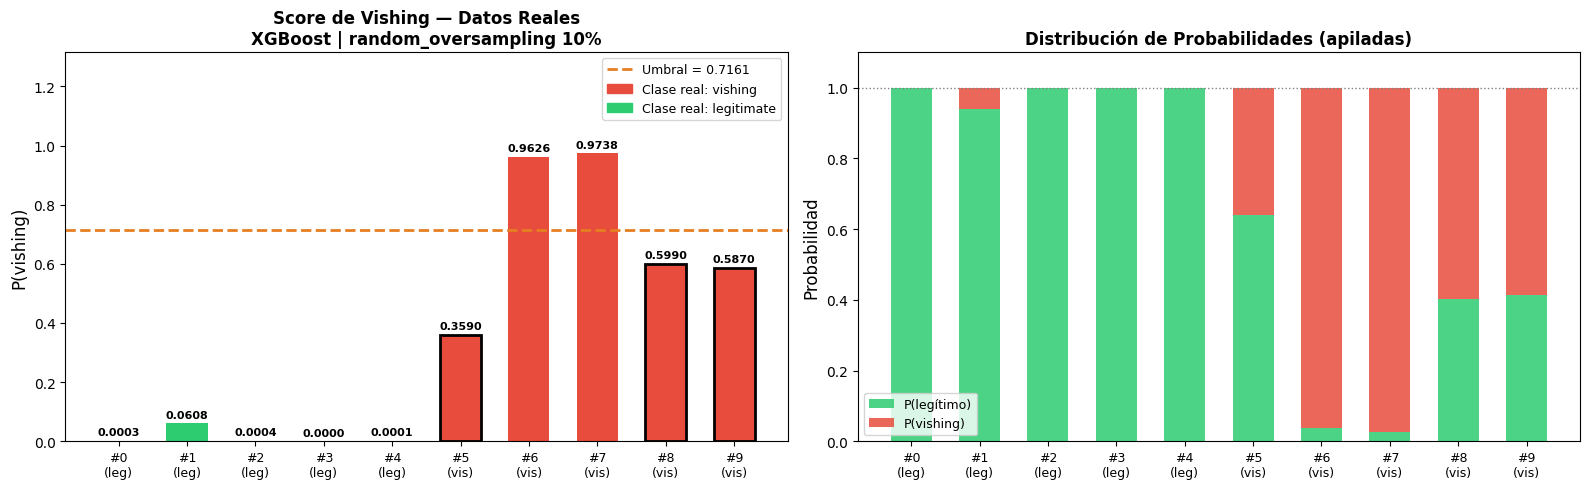

Verde = legítima real  |  Rojo = vishing real  |  Borde negro = clasificación incorrecta
Umbral: 0.7161  — por encima → VISHING


In [28]:
labels_real  = [('vishing' if r == 1 else 'legitimate') for r in y_real]
p_vishing_r  = [r['probability_vishing']    for r in results_real]
p_legitimo_r = [r['probability_legitimate'] for r in results_real]
pred_labels  = [r['label']                  for r in results_real]
umbral       = wrapper.threshold

x      = np.arange(len(results_real))
colores = ['#e74c3c' if real == 'vishing' else '#2ecc71' for real in labels_real]
borde   = ['black' if pred != real else 'none'
           for pred, real in zip(pred_labels, labels_real)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Score de vishing por observación ─────────────────────────────────────────
bars = axes[0].bar(x, p_vishing_r, color=colores, edgecolor=borde,
                   linewidth=2, width=0.6)
axes[0].axhline(umbral, color='#e67e22', linestyle='--', linewidth=2,
                label=f'Umbral = {umbral:.4f}')
axes[0].set_ylim(0, max(p_vishing_r) * 1.3 + 0.05)
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [f'#{i}\n({lbl[:3]})' for i, lbl in enumerate(labels_real)], fontsize=9)
axes[0].set_ylabel('P(vishing)', fontsize=12)
axes[0].set_title(
    f'Score de Vishing — Datos Reales\n{wrapper.model_name} | {wrapper.technique} {wrapper.ratio}%',
    fontweight='bold')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, p_vishing_r):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(p_vishing_r) * 0.02,
                 f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')

import matplotlib.patches as mpatches
axes[0].legend(handles=[
    axes[0].get_lines()[0],
    mpatches.Patch(color='#e74c3c', label='Clase real: vishing'),
    mpatches.Patch(color='#2ecc71', label='Clase real: legitimate'),
], fontsize=9)

# ── Probabilidades apiladas ───────────────────────────────────────────────────
axes[1].bar(x, p_legitimo_r, label='P(legítimo)', color='#2ecc71', alpha=0.85, width=0.6)
axes[1].bar(x, p_vishing_r, bottom=p_legitimo_r, label='P(vishing)',
            color='#e74c3c', alpha=0.85, width=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [f'#{i}\n({lbl[:3]})' for i, lbl in enumerate(labels_real)], fontsize=9)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Probabilidad', fontsize=12)
axes[1].set_title('Distribución de Probabilidades (apiladas)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].axhline(1.0, color='gray', linestyle=':', linewidth=1)

plt.tight_layout()
plt.show()

print(f'Verde = legítima real  |  Rojo = vishing real  |  Borde negro = clasificación incorrecta')
print(f'Umbral: {umbral:.4f}  — por encima → VISHING')


## 9. Perfil de Riesgo Comparativo — Radar

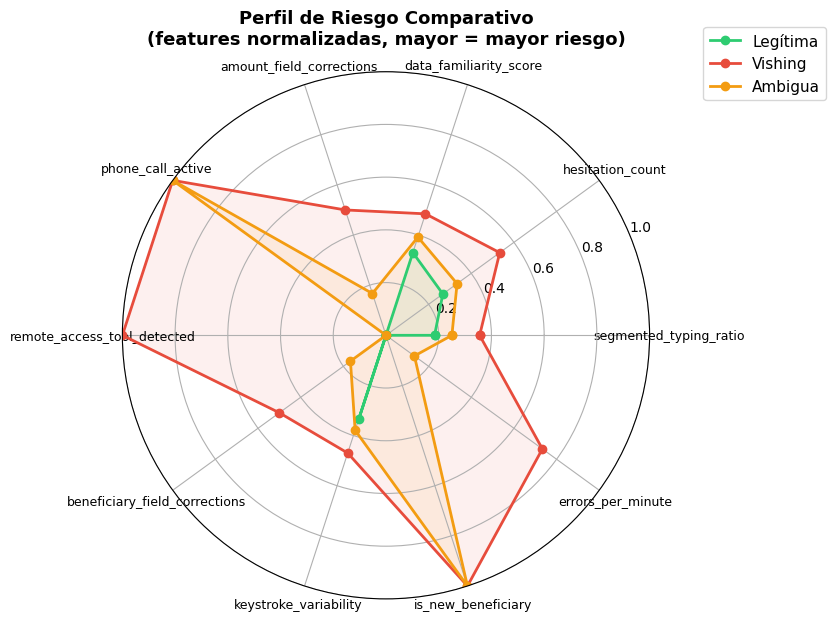

In [29]:
# Features más discriminativas según el EDA (selección manual top-10)
RISK_FEATURES = [
    'segmented_typing_ratio',
    'hesitation_count',
    'data_familiarity_score',
    'amount_field_corrections',
    'phone_call_active',
    'remote_access_tool_detected',
    'beneficiary_field_corrections',
    'keystroke_variability',
    'is_new_beneficiary',
    'errors_per_minute',
]

# Rangos del EDA para normalizar a [0, 1]
RANGES = {
    'segmented_typing_ratio'    : (0.0, 0.76),
    'hesitation_count'          : (0,   15),
    'data_familiarity_score'    : (0.03, 1.0),
    'amount_field_corrections'  : (0,   6),
    'phone_call_active'         : (0,   1),
    'remote_access_tool_detected': (0,  1),
    'beneficiary_field_corrections': (0, 6),
    'keystroke_variability'     : (0.0, 0.66),
    'is_new_beneficiary'        : (0,   1),
    'errors_per_minute'         : (0.0, 0.15),
}
# Para data_familiarity_score el riesgo es INVERSO (mayor score → menos riesgo)
INVERTED = {'data_familiarity_score'}

def normalise(feat, val):
    lo, hi = RANGES[feat]
    norm = (val - lo) / (hi - lo) if hi > lo else 0.0
    norm = max(0.0, min(1.0, norm))
    return 1 - norm if feat in INVERTED else norm

colores_radar = {'Legítima': '#2ecc71', 'Vishing': '#e74c3c', 'Ambigua': '#f39c12'}
angles = np.linspace(0, 2 * np.pi, len(RISK_FEATURES), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for nombre, sesion in casos.items():
    vals = [normalise(f, sesion[f]) for f in RISK_FEATURES] + [normalise(RISK_FEATURES[0], sesion[RISK_FEATURES[0]])]
    ax.plot(angles, vals, 'o-', color=colores_radar[nombre], linewidth=2,
            label=nombre, markersize=6)
    ax.fill(angles, vals, alpha=0.08, color=colores_radar[nombre])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RISK_FEATURES, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Perfil de Riesgo Comparativo\n(features normalizadas, mayor = mayor riesgo)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

## 10. Validaciones y Manejo de Errores

In [30]:
print('=== TEST 1: Feature faltante ===')
input_incompleto = {k: v for k, v in session_vishing.items() if k != 'phone_call_active'}
try:
    wrapper.predict_full(input_incompleto)
    print('  ❌ Debería haber fallado')
except ValueError as e:
    print(f'  ✅ Error capturado correctamente: {e}')

print()
print('=== TEST 2: JSON string inválido ===')
try:
    wrapper.predict_full('{"campo_incorrecto": 999}')
    print('  ❌ Debería haber fallado')
except ValueError as e:
    print(f'  ✅ Error capturado: missing {len(wrapper.feature_names) - 1} features (se muestra solo la primera):')
    print(f'     {str(e)[:120]}...')

print()
print('=== TEST 3: Input con features extra (deben ser ignoradas si no hay error) ===')
# El wrapper filtra por feature_names, las extras sencillamente no se usan
input_con_extras = {**session_legitima, 'campo_extra': 99999, 'otro_campo': 'abc'}
try:
    res = wrapper.predict_full(input_con_extras)
    print(f'  ✅ Predicción exitosa ignorando campos extra → label={res["label"]}')
except Exception as e:
    print(f'  Resultado: {e}')

print()
print('=== TEST 4: Tipo de input incorrecto ===')
try:
    wrapper.predict_full(12345)
    print('  ❌ Debería haber fallado')
except TypeError as e:
    print(f'  ✅ TypeError capturado: {e}')

=== TEST 1: Feature faltante ===
  ✅ Error capturado correctamente: Missing features: ['phone_call_active']

=== TEST 2: JSON string inválido ===
  ✅ Error capturado: missing 43 features (se muestra solo la primera):
     Missing features: ['accelerometer_jerk_mean', 'amount_field_corrections', 'avg_hesitation_duration_s', 'avg_interkey_lat...

=== TEST 3: Input con features extra (deben ser ignoradas si no hay error) ===
  ✅ Predicción exitosa ignorando campos extra → label=legitimate

=== TEST 4: Tipo de input incorrecto ===
  ✅ TypeError capturado: Expected dict, JSON string, or list of dicts. Got <class 'int'>


## 11. Resumen Final

In [31]:
print('═' * 65)
print('  RESUMEN DE INFERENCIA')
print('═' * 65)
print(f'  Modelo      : {wrapper.model_name}')
print(f'  Técnica     : {wrapper.technique}  |  Ratio: {wrapper.ratio}%')
print(f'  Umbral      : {wrapper.threshold:.4f}')
print(f'  N features  : {len(wrapper.feature_names)}')
print('─' * 65)
print(f'  {"Caso":<12}  {"Score vishing":>14}  {"Decisión":>12}')
print('─' * 65)
for nombre, res in zip(nombres_batch, batch_results):
    flag = '⚠️  ALERTA' if res['prediction'] == 1 else '✅  OK'
    print(f'  {nombre:<12}  {res["probability_vishing"]:>14.6f}  {flag}')
print('═' * 65)
print()
print('API disponible en el wrapper:')
print('  wrapper.predict(json)           → int (0 o 1)')
print('  wrapper.predict_proba_raw(json) → dict {legitimate, vishing}')
print('  wrapper.predict_full(json)      → dict completo')
print('  Todos aceptan: dict | str JSON | list[dict] para batch')

═════════════════════════════════════════════════════════════════
  RESUMEN DE INFERENCIA
═════════════════════════════════════════════════════════════════
  Modelo      : XGBoost
  Técnica     : random_oversampling  |  Ratio: 10%
  Umbral      : 0.7161
  N features  : 44
─────────────────────────────────────────────────────────────────
  Caso           Score vishing      Decisión
─────────────────────────────────────────────────────────────────
  Legítima            0.000027  ✅  OK
  Vishing             0.000241  ✅  OK
  Ambigua             0.000176  ✅  OK
═════════════════════════════════════════════════════════════════

API disponible en el wrapper:
  wrapper.predict(json)           → int (0 o 1)
  wrapper.predict_proba_raw(json) → dict {legitimate, vishing}
  wrapper.predict_full(json)      → dict completo
  Todos aceptan: dict | str JSON | list[dict] para batch
